# Lab 6
### Morphology

Skimage morphology operators' documentation:
https://scikit-image.org/docs/dev/api/skimage.morphology.html

In [45]:
from commonfunctions import *
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.morphology import binary_erosion, binary_dilation, binary_closing,skeletonize, thin, footprint_rectangle
from skimage.measure import find_contours
from skimage.draw import rectangle



# Show the figures / plots inside the notebook
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


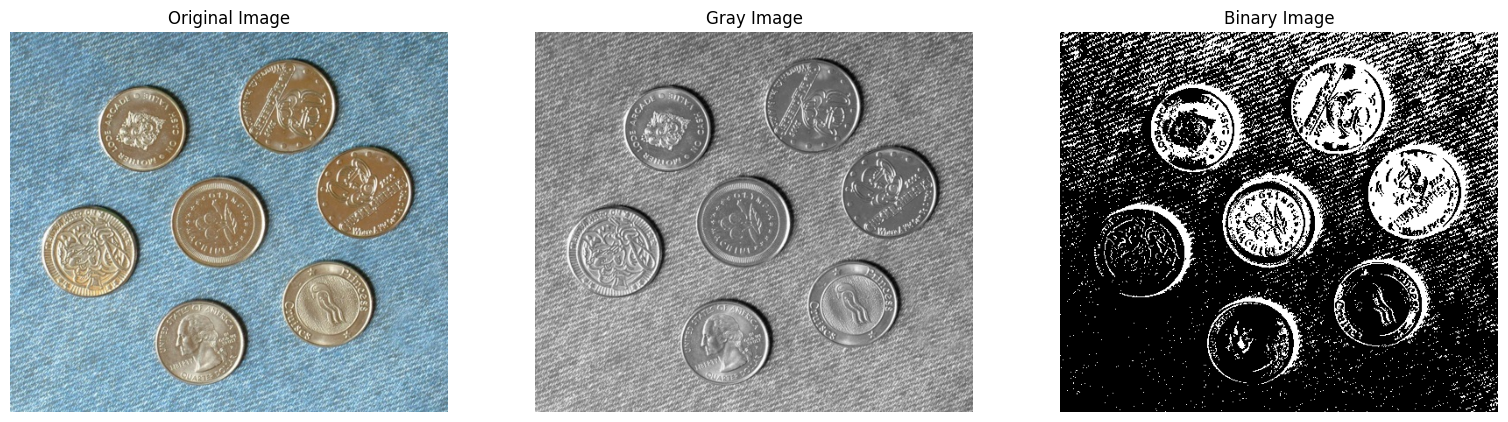

In [56]:
'''
1) Erosion / Dilation:
    - Load "coins.jpg" from the img folder
    - Convert the image to binary
    - Write 2 functions each applying 1 of the erosion/dilation algorithms (with adjustable square window size) manually to the binary image
    - Use Skimage's "binary_erosion" & "binary_dilation" & show the results
'''
img = io.imread("./img/coins.jpg")
gray_img = rgb2gray(img)

th = 0.5
binary_img = gray_img < th
show_images([img, gray_img, binary_img], ["Original Image", "Gray Image", "Binary Image"])



In [22]:
# manual erosion
def manual_erosion(binary_image, window_size):
    pad_size = window_size // 2
    padded_image = np.pad(binary_image, pad_size, mode='constant', constant_values=1)
    eroded_image = np.zeros_like(binary_image)

    for i in range(eroded_image.shape[0]):
        for j in range(eroded_image.shape[1]):
            region = padded_image[i:i + window_size, j:j + window_size]
            if np.all(region):
                eroded_image[i, j] = 1
            else:
                eroded_image[i, j] = 0

    return eroded_image

# manual dilation
def manual_dilation(binary_image, window_size):
    pad_size = window_size // 2
    padded_image = np.pad(binary_image, pad_size, mode='constant', constant_values=0)
    dilated_image = np.zeros_like(binary_image)

    for i in range(dilated_image.shape[0]):
        for j in range(dilated_image.shape[1]):
            region = padded_image[i:i + window_size, j:j + window_size]
            if np.any(region):
                dilated_image[i, j] = 1
            else:
                dilated_image[i, j] = 0

    return dilated_image

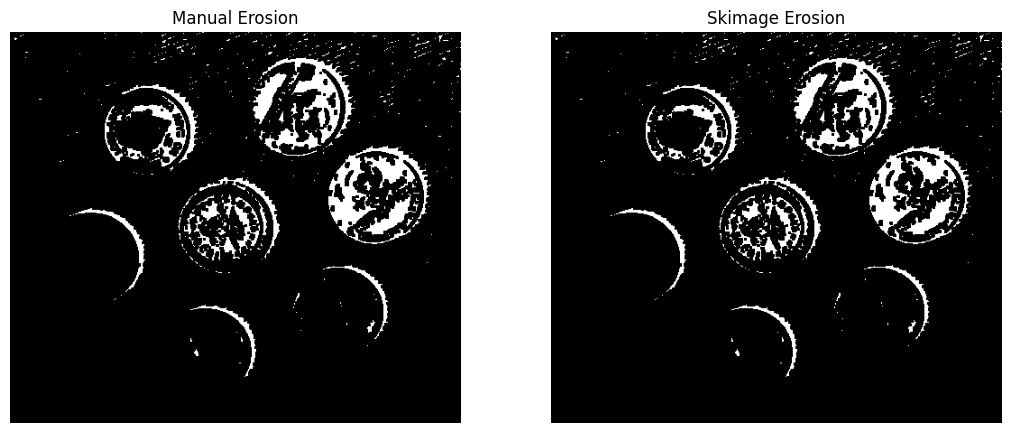

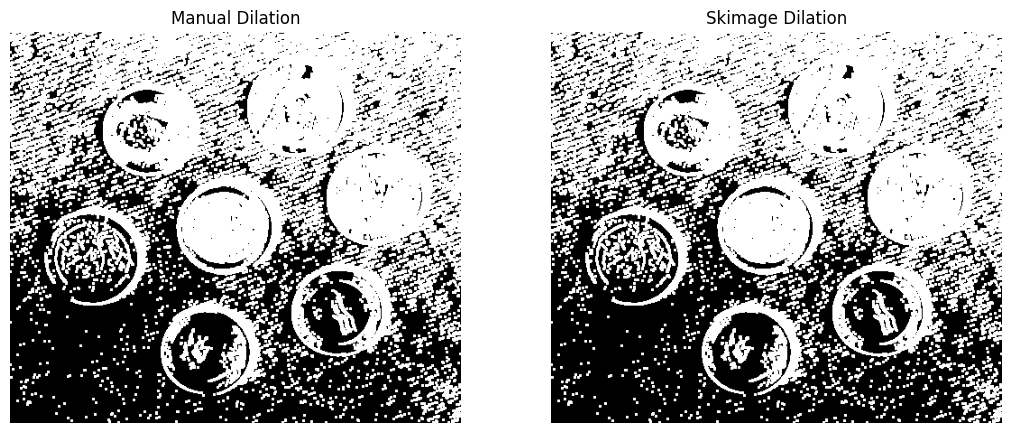

In [64]:
# compare results
window_size = 3
window_matrix = np.ones((3,3), dtype=bool)
manual_eroded = manual_erosion(binary_img, window_size)
skimage_eroded = binary_erosion(binary_img, footprint=window_matrix)  
manual_dilated = manual_dilation(binary_img, window_size)
skimage_dilated = binary_dilation(binary_img, footprint=window_matrix)

# Display results
show_images([manual_eroded, skimage_eroded], ["Manual Erosion", "Skimage Erosion"])
show_images([manual_dilated, skimage_dilated], ["Manual Dilation", "Skimage Dilation"])

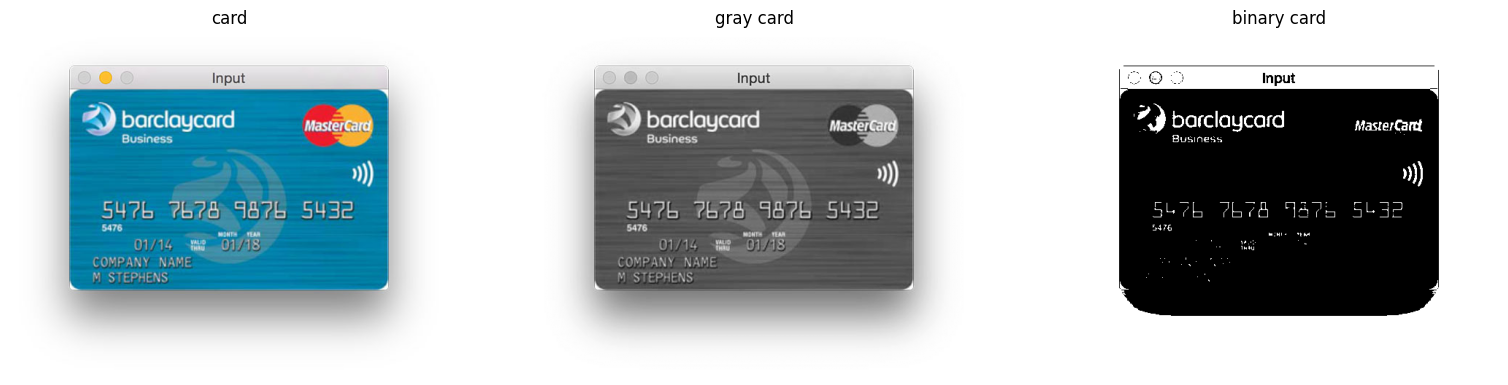

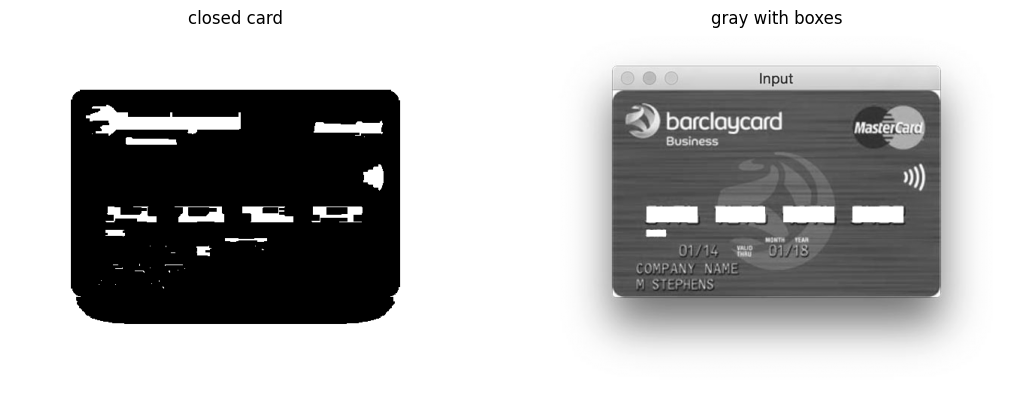

In [55]:
'''
2) Case Study: Credit Card Number Extraction
    - Load "card.jpg" from the img folder
    - Convert the image to binary by brightness thresholding maintaining the card number details for extraction
    - Use your erosion/dilation functions, or Skimage's functions only if you didn't implement them, to apply closing
        Note: The goal of this step is to join the card number into 4 sets of connected pixels
    - Use Skimage's "find_contours" to get the bounding boxes for the credit card's numbers by filtering on aspect ratio (between 2.5 & 3.5)
        Note: When using "find_contours(img, 0.8)" the o/p is a list of contours each having:
                - contour[:,0] being the Y values of the contour perimeter points
                - contour[:,1] being the X values of the contour perimeter points
'''
card = io.imread("./img/card.jpg")
card_gray = rgb2gray(card)

threshold = 0.75
card_binary = card_gray > threshold  

window_size = 15
footprint = footprint_rectangle((3,20))
card_closed = binary_closing(card_binary, footprint=footprint)

contours = find_contours(card_closed, 0.8)

bounding_boxes = []

for contour in contours:
    Ymin, Ymax = np.min(contour[:,0]), np.max(contour[:,0])
    Xmin, Xmax = np.min(contour[:,1]), np.max(contour[:,1])
    
    width  = Xmax - Xmin
    height = Ymax - Ymin
    
    if height == 0: 
        continue
    
    aspect_ratio = width / height
    if 2.5 <= aspect_ratio <= 3.5:
        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])

img_with_boxes = np.copy(card_gray)

for box in bounding_boxes:
    [Xmin, Xmax, Ymin, Ymax] = box
    rr, cc = rectangle(start = (Ymin,Xmin), end = (Ymax,Xmax), shape=card_gray.shape)
    img_with_boxes[rr, cc] = 1 

show_images([card, card_gray, card_binary], ["card", "gray card", "binary card"])
show_images([card_closed, img_with_boxes], ["closed card", "gray with boxes"]) 

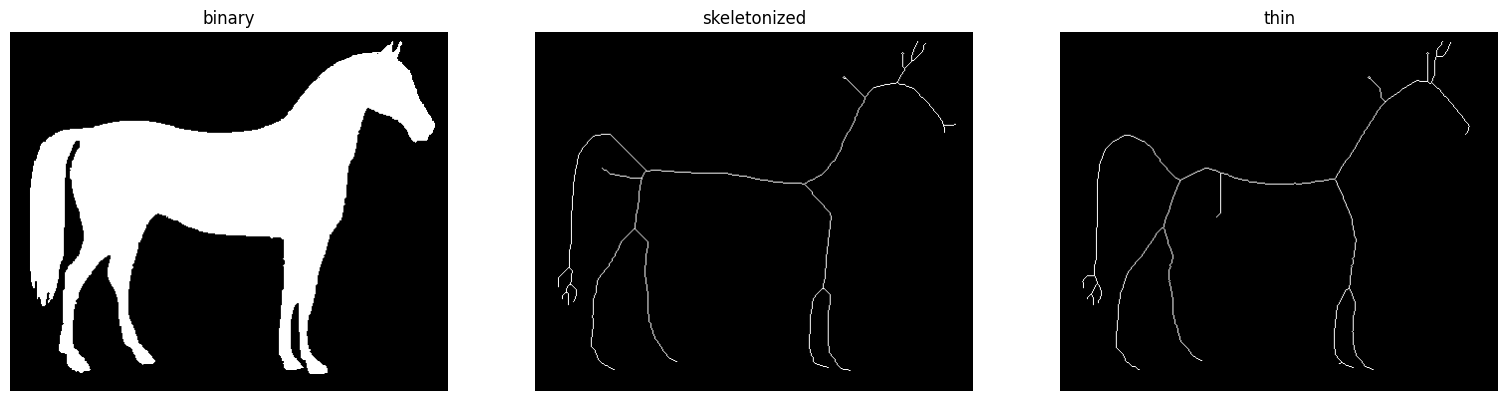

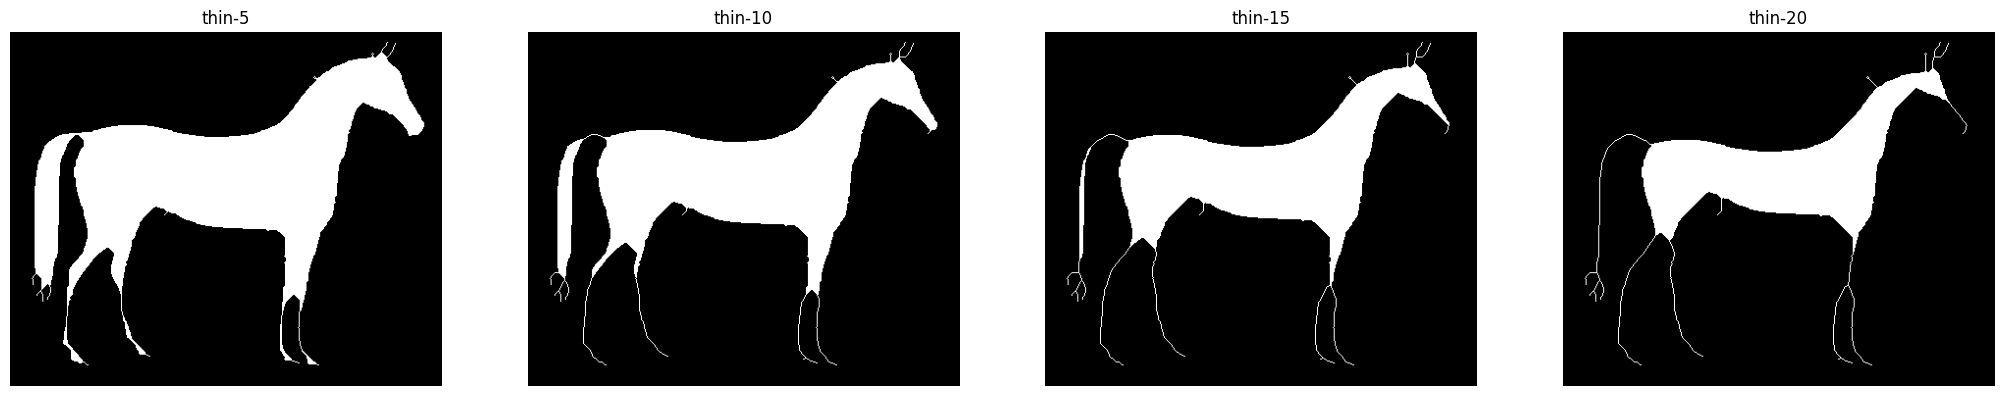

In [63]:
'''
3) Skeletonization:
    - Load "horse.jpg" from the img folder 
    - Use a binary threshold of 0.9 to remove invisible noise in the background
    - Use Skimage's "skeletonize(image)" to acquire the image's skeleton & show it
    - Use Skimage's "thin(image, max_iter)" with values of max_iter 5/10/15/20 & show it
'''


horse_img = io.imread("./img/horse.jpg")
gray_horse_img = rgb2gray(horse_img)
binary_horse_img = gray_horse_img > 0.9
skeletonized_img = skeletonize(binary_horse_img)
thin_img = thin(binary_horse_img)
thin_img_5 = thin(binary_horse_img, max_num_iter=5)
thin_img_10 = thin(binary_horse_img, max_num_iter=10)
thin_img_15 = thin(binary_horse_img, max_num_iter=15)
thin_img_20 = thin(binary_horse_img, max_num_iter=20)

# Display results
show_images([binary_horse_img, skeletonized_img, thin_img],["binary", "skeletonized", "thin"])
show_images([thin_img_5, thin_img_10, thin_img_15, thin_img_20],["thin-5", "thin-10", "thin-15", "thin-20"])